In [ ]:
# Pricing d'une Option Européenne via Monte CarloLe 
# --> Simuler N trajectoires d'un actif financier sur M pas de temps 
# --> Suivant un Mouvement Brownien Géométrique (GBM)
# --> Calculer le prix d'un Call Européen

# L'équation de la dynamique du prix de l'actif entre deux instants est:
# S_{t+Delta t} = S_t*exp((r - (sigma^2)/2 * Delta t + sigma*sqrt{\Delta t}*Z
# Z est une normale centrée réduite.

In [ ]:
# Les contraintes pour l'exercice :
# --> Zéro boucle for pour la simulation des trajectoires.
# --> Générer une matrice de dimensions (M+1, N) où chaque colonne représente une trajectoire complète de l'actif du temps 0 à T.
# --> Calculer le payoff moyen actualisé pour obtenir le prix de l'option.

In [ ]:
# Les Données du Problème 
# --> S_0 = 100$ (Prix initial de l'actif)
# --> K = 105$ (Prix d'exercice / Strike)
# --> T = 1.0$ (Maturité en année)
# --> r = 0.05$ (Taux d'intérêt sans risque, soit 5%)
# --> sigma = 0.20$ (Volatilité, soit 20%)
# --> N = 100 000 (Nombre de trajectoires à simuler)
# --> M = 252$ (Nombre de pas de temps, correspondant aux jours de trading dans une année)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Paramètres
S0 = 100       # Prix initial
K = 105       # Strike
T = 1.0       # Maturité (1 an)
r = 0.05      # Taux sans risque (5%)
sigma = 0.20  # Volatilité (20%)
N = 100000    # Nombre de trajectoires (colonnes)
M = 252       # Nombre de pas de temps (lignes)

dt = T / M

# 2. Génération du hasard (Matrice M x N)
# Z représente les chocs aléatoires journaliers pour chaque scénario
Z = np.random.normal(0, 1, size=(M, N))

# 3. Calcul des rendements journaliers (Vectorisé)
# On applique la formule de l'exposant pour chaque case d'un coup
rendements = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# 4. Somme cumulée pour simuler l'évolution du temps (axis=0 -> verticalement)
rendements_cumules = np.cumsum(rendements, axis=0)

# 5. Reconstruction des prix de l'actif
# On ajoute une ligne de zéros au début pour le jour 0 (où exp(0) = 1)
zeros_initiaux = np.zeros((1, N))
rendements_complets = np.vstack([zeros_initiaux, rendements_cumules])

# Matrice finale des prix (Taille: 253 x 100 000)
S = S0 * np.exp(rendements_complets)

# 6. Calcul du Payoff à Maturité (Dernière ligne de la matrice : S[-1])
payoffs = np.maximum(S[-1] - K, 0)

# 7. Moyenne des payoffs et actualisation (Discounts)
prix_option = np.exp(-r * T) * np.mean(payoffs)

print(f"Le prix de l'option Call Européen est de : {prix_option:.4f} €")

Le prix de l'option Call Européen est de : 8.0374 €


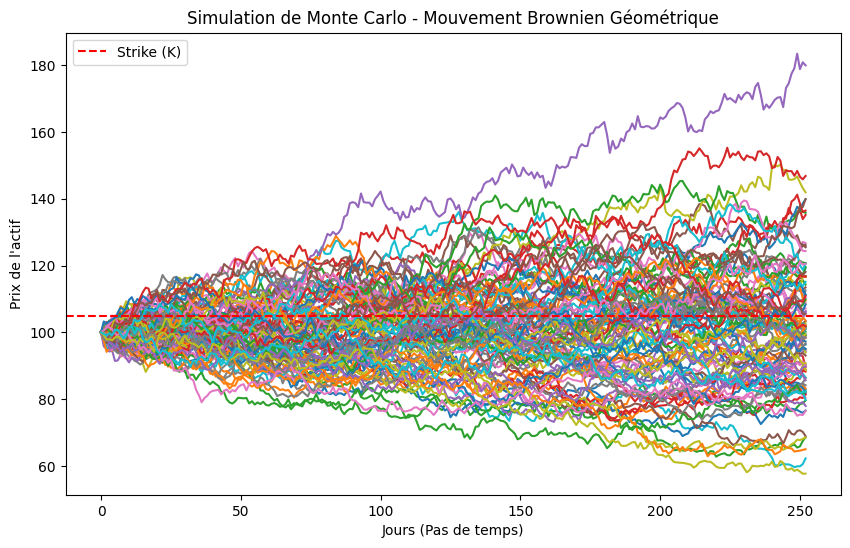

In [2]:
plt.figure(figsize=(10, 6))
plt.plot(S[:, :100])  # On affiche les 100 premières colonnes
plt.axhline(K, color='red', linestyle='--', label='Strike (K)')
plt.title("Simulation de Monte Carlo - Mouvement Brownien Géométrique")
plt.xlabel("Jours (Pas de temps)")
plt.ylabel("Prix de l'actif")
plt.legend()
plt.show()